---
#<font color="#CA3532">Neurocomputing Practice 3 – Academic Year 2025–2026</font>
### School of Engineering – Autonomous University of Madrid

---
- Start date: Thursday, 08-04-2026
- Submission deadline: Thursday, 05-05-2023

---

Last updated: 01-04-2026

In [1]:
### Incluid vuestros nombres, pareja y grupo aquí:
estudiantes = [
    {'nombre': 'nombre del primer estudiante'},
    {'nombre': 'nombre del segundo estudiante'}
]

Many binary classification problems do not have the same number of examples for each class. In these cases, the class distribution is said to be biased or unbalanced.

An example of this problem is found in speech recognizers that classify vowel sounds in European languages as either nasal or oral. Accuracy in classification is important for both classes, but it cannot be used in problems with unbalanced classes.

# <font color="#CA3532">Phoneme Dataset</font>


To characterize each vowel, five different attributes have been selected: the amplitudes of the first five harmonics (AHi), normalized by the total energy (Ene): AHi/Ene. Each harmonic can be positive if it corresponds to a local maximum in the spectrum, or negative otherwise.

In the *Phoneme Dataset*, there are two classes for the two types of sounds:
*	Class 0: nasal vowels (the majority class).
*	Class 1: oral vowels (the minority class).


In [2]:
# Details https://raw.githubusercontent.com/jbrownlee/Datasets/master/phoneme.names
dataset_url = 'https://raw.githubusercontent.com/jbrownlee/Datasets/master/phoneme.csv'

# <font color="#CA3532">Exploración de los datos</font>

In [3]:
from pandas import read_csv
from pandas import DataFrame
from pandas.plotting import scatter_matrix
from matplotlib import pyplot
from collections import Counter

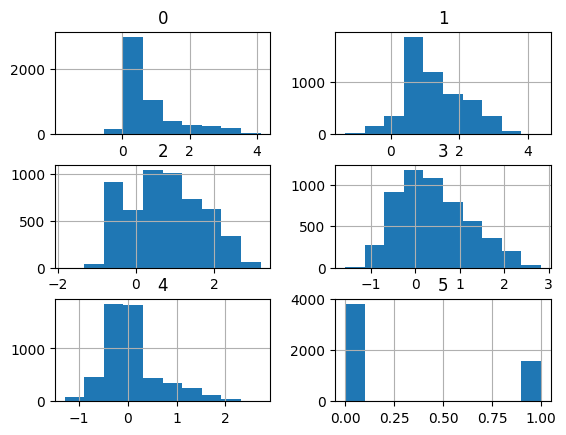

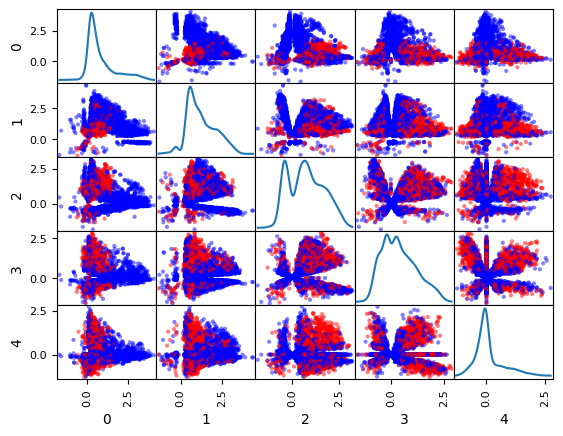

In [4]:
# define the dataset location
filename = dataset_url
# load the csv file as a data frame
df = read_csv(filename, header=None)
# histograms of all variables
df.hist()
pyplot.show()
# define a mapping of class values to colors
color_dict = {0:'blue', 1:'red'}
# map each row to a color based on the class value
colors = [color_dict[x] for x in df.values[:, -1]]
# drop the target variable
inputs = DataFrame(df.values[:, :-1])
# pairwise scatter plots of all numerical variables scatter_matrix(inputs, diagonal='kde', color=colors)
scatter_matrix(inputs, diagonal='kde', color=colors)
pyplot.show()

### Question 1: What is the class distribution of examples?  
Explain here what the previous plots represent and what you observe in them.

**Respuesta:**

1.  **Histogramas (Primera figura):** Representan la distribución de frecuencias de cada una de las 6 variables del conjunto de datos. Las gráficas del 0 al 4 corresponden a las características de entrada (amplitudes de los armónicos). La última gráfica inferior derecha muestra la distribución de la variable objetivo (la clase). En esta última gráfica se observa claramente el **desbalanceo de clases**, mostrando que la clase 0 (vocales nasales, la clase mayoritaria) tiene cerca de 4000 ejemplos, frente a la clase 1 (vocales orales, minoritaria) que apenas supera los 1500 ejemplos.

2.  **Matriz de dispersión o Scatter Matrix (Segunda figura):** Muestra todas las combinaciones de pares posibles entre las 5 características de entrada. 
    *   En la **diagonal principal** se muestra una estimación de la densidad de probabilidad (KDE), que es una curva continua que suaviza el histograma de cada característica.
    *   En el **resto de celdas**, se dibujan gráficos de dispersión combinando características dos a dos, con los puntos coloreados según su clase (azul para la 0 y rojo para la 1).
    *   **Observación:** Hay un alto nivel de solapamiento entre los ejemplos de ambas clases (puntos azules y rojos mezclados) en casi todas las dimensiones. Esto indica que el problema de clasificación es complejo y que las clases no son fácilmente separables mediante fronteras de decisión simples (como modelos lineales).

# <font color="#CA3532">Modelling</font>

- In this practice, we will use [Keras](https://keras.io/)

- Keras is an open-source neural network library designed for experimenting with deep neural networks. Keras is modular, extensible, and easy to use.

- Keras can run on different backends. Here, it will be used with TensorFlow.

In [7]:
# Imports

import numpy as np
import matplotlib.pyplot as plt

import tensorflow as tf
from tensorflow import keras

import keras as k
from keras.models import Sequential
from keras.layers import Dense

from sklearn.preprocessing import StandardScaler

In [10]:
dataset = np.loadtxt(dataset_url, delimiter=',')

print(dataset)

### -------------------------------------------------------------------------------
### Split the examples into features and classes. Store the number of features.
### -------------------------------------------------------------------------------

x = dataset[:, :-1]
x_size = x.shape[1]
y = dataset[:, -1]

[[ 1.24   0.875 -0.205 -0.078  0.067  0.   ]
 [ 0.268  1.352  1.035 -0.332  0.217  0.   ]
 [ 1.567  0.867  1.3    1.041  0.559  0.   ]
 ...
 [ 1.031  0.584  1.866  1.532 -0.671  1.   ]
 [ 0.15   0.933  2.363 -0.742 -0.617  0.   ]
 [ 0.137  0.714  1.35   0.972 -0.63   1.   ]]


In [11]:
# Results of the split and the number of features
print(x)
print(y)
print(x_size)

[[ 1.24   0.875 -0.205 -0.078  0.067]
 [ 0.268  1.352  1.035 -0.332  0.217]
 [ 1.567  0.867  1.3    1.041  0.559]
 ...
 [ 1.031  0.584  1.866  1.532 -0.671]
 [ 0.15   0.933  2.363 -0.742 -0.617]
 [ 0.137  0.714  1.35   0.972 -0.63 ]]
[0. 0. 0. ... 1. 0. 1.]
5


In [12]:
# Normalize the data (if necessary)
scaler = StandardScaler()
scaler.fit(x)
x = scaler.transform(x)

## <font color="#CA3532">Neural Network Definition</font>

- Each layer of the model has a set of defined properties (size, activation function, connectivity, etc.) which you can find at https://keras.io/api/layers/core_layers/dense/.

- We will use Keras' Sequential model to create a multi-layer feedforward neural network.


In [23]:
# Define the model with Keras
from keras.layers import Dropout

nn = Sequential()

### -------------------------------------------------------------------------------
### Add the fully connected layers you consider appropriate to the model
### -------------------------------------------------------------------------------

# Arquitectura más profunda: aumentamos neuronas y cambiamos la activación a ReLU (aprende mejor)
nn.add(Dense(32, input_dim=x_size, activation="relu"))
# Añadimos Dropout para apagar aleatoriamente neuronas y evitar sobreajuste (overfitting)
nn.add(Dropout(0.2))
# Añadimos una capa oculta extra
nn.add(Dense(16, activation="relu"))

# Capa de salida: 1 neurona porque es clasificación binaria (siempre en sigmoid)
nn.add(Dense(1, activation="sigmoid"))

/home/ignacio/Escritorio/NEURO/Neuro/.venv/lib/python3.12/site-packages/keras/src/layers/core/dense.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


## <font color="#CA3532">Neural Network Compilation</font>

- Compilation is the operation that builds the neural network.

- Compilation includes aspects that will be taken into account during the training of the neural network.

- In the sections below, you will find links to the official documentation where you can learn more about the different strategies for each aspect.

- It is also possible to define your own functions.

#### <font color="#CA3532">Optimizer</font>

The optimizer is the strategy used to compute weight updates.

https://keras.io/api/optimizers/

In [24]:
optimizer = "Adam"
# optimizer = "SGD"

#### <font color="#CA3532">Loss Function</font>

The loss function calculates the quantity the model aims to minimize during training.

https://keras.io/api/losses/

In [25]:
# loss = "mse"
loss = "binary_crossentropy"

#### <font color="#CA3532">Metrics</font>

A metric is a function that evaluates the performance of the model. Metrics are similar to loss functions, but unlike loss functions, they are not used during training—they are applied to the results. Loss functions can also be used as metrics.

https://keras.io/api/metrics/

In [26]:
metrics = [
            #keras.metrics.TruePositives(name='tp'),
            #keras.metrics.FalsePositives(name='fp'),
            #keras.metrics.TrueNegatives(name='tn'),
            #keras.metrics.FalseNegatives(name='fn'),
            keras.metrics.BinaryAccuracy(name='ACC'),
            keras.metrics.Precision(name='P'),
            keras.metrics.Recall(name='R'),
            keras.metrics.AUC(name='auc'),
            keras.metrics.AUC(name='PRC', curve='PR'),
          ]

In [27]:
# nn.compile(optimizer='SGD', loss="mse", metrics="accuracy")
nn.compile(optimizer=optimizer, loss=loss, metrics=metrics)

### Question 2: Explain in detail the metrics and loss functions that are relevant for this problem and describe how they are calculated. Explain why *accuracy* is not a good metric for unbalanced problems. What are ROC and PR curves, and what are they used for?

**Respuesta:**

**1. Funciones de Pérdida (Loss Functions) relevantes:**
Para este problema de clasificación binaria ("vocales nasales" vs "vocales orales"), la función de pérdida adecuada es la **Entropía Cruzada Binaria (Binary Crossentropy)**. 
- *Cómo se calcula:* Penaliza las predicciones del modelo comparando la probabilidad predicha (entre 0 y 1) con la clase real (0 o 1). Matemáticamente, utiliza el logaritmo de las probabilidades predichas. Si el modelo asegura con alta probabilidad una predicción que resulta ser incorrecta, la penalización crece exponencialmente.

**2. Métricas relevantes:**
Dado el desbalanceo, nos interesan métricas que evalúen bien a la clase minoritaria:
- **Precisión (Precision):** Representa "De todos los que predije como clase oral (1), ¿cuántos lo eran realmente?". Se calcula como: `Verdaderos Positivos / (Verdaderos Positivos + Falsos Positivos)`.
- **Sensibilidad (Recall):** Representa "De todas las vocales orales reales (1), ¿cuántas logró detectar mi modelo?". Se calcula como: `Verdaderos Positivos / (Verdaderos Positivos + Falsos Negativos)`.

**3. Por qué la Exactitud (Accuracy) no es buena en problemas desbalanceados:**
La *exactitud* mide la proporción total de predicciones correctas (`Aciertos Totales / Total de Ejemplos`). En un dataset donde la clase 0 representa (por ejemplo) el 80% de los datos y la clase 1 el 20%, un modelo "ciego" que predeciría siempre la clase 0 obtendría un **80% de exactitud**. Esto daría la falsa sensación de ser un gran modelo, cuando en la práctica fracasa rotundamente localizando a la clase minoritaria (0% de Recall para la clase 1).

**4. Curvas ROC y PR (Precision-Recall):**
Para tomar una decisión final, la neurona de salida emite una probabilidad y necesita un "umbral" (usualmente 0.5) para elegir clase. Las curvas se utilizan para evaluar esto sin atarnos a un solo umbral:
- **Curva ROC:** Muestra la relación entre la *Tasa de Verdaderos Positivos* (Recall) y la *Tasa de Falsos Positivos* a lo largo de todos los umbrales posibles (de 0 a 1). Se resume calculando el área bajo la curva (AUC).
- **Curva PR:** Muestra la relación directa entre la *Precision* y el *Recall* a lo largo de distintos umbrales. **Se utiliza principalmente en conjuntos de datos muy desbalanceados**, porque estas dos métricas no incluyen en su cálculo a los Verdaderos Negativos. Evalúa cuán bien el modelo rinde *exclusivamente* en concentrarse en los casos positivos (la clase minoritaria que realmente importa), sin verse maquillado por la sobreabundancia de la clase mayoritaria.

## <font color="#CA3532">Neural Network Training</font>

The "fit" method trains a neural network with the provided data.

We will use 20% of the data for validation, although other validation methods are allowed, including parameter optimization.

https://keras.io/api/models/model_training_apis/#fit-method

In [28]:
from sklearn.model_selection import train_test_split

# Hacemos la partición de los datos. Se recomienda usar stratify=y para 
# mantener la proporción de la clase minoritaria en entrenamiento y validación.
# También fijamos un random_state para reproducibilidad.
x_train, x_val, y_train, y_val = train_test_split(x, y, test_size=0.2, stratify=y, random_state=42)

# Entrenamos el modelo. 
# Hemos puesto verbose=1 para que puedas ver el progreso del entrenamiento.
# Aumentamos los epochs a 50 para darle suficiente tiempo a la red neuronal profunda a aprender y estabilizarse.
history = nn.fit(x_train, y_train, epochs=50, verbose=1, validation_data=(x_val, y_val))

# Mostramos el resumen de la arquitectura de la red
nn.summary()

Epoch 1/50
136/136 ━━━━━━━━━━━━━━━━━━━━ 3s 5ms/step - ACC: 0.7442 - P: 0.5750 - PRC: 0.5289 - R: 0.4925 - auc: 0.7680 - loss: 0.5303 - val_ACC: 0.7456 - val_P: 0.5833 - val_PRC: 0.6007 - val_R: 0.4637 - val_auc: 0.8025 - val_loss: 0.4753
Epoch 2/50
136/136 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - ACC: 0.7724 - P: 0.6264 - PRC: 0.6153 - R: 0.5563 - auc: 0.8299 - loss: 0.4499 - val_ACC: 0.7641 - val_P: 0.6026 - val_PRC: 0.6227 - val_R: 0.5741 - val_auc: 0.8145 - val_loss: 0.4598
Epoch 3/50
136/136 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - ACC: 0.7819 - P: 0.6361 - PRC: 0.6480 - R: 0.6005 - auc: 0.8430 - loss: 0.4335 - val_ACC: 0.7586 - val_P: 0.6138 - val_PRC: 0.6391 - val_R: 0.4763 - val_auc: 0.8251 - val_loss: 0.4502
Epoch 4/50
136/136 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - ACC: 0.7842 - P: 0.6489 - PRC: 0.6619 - R: 0.5768 - auc: 0.8506 - loss: 0.4229 - val_ACC: 0.7798 - val_P: 0.6396 - val_PRC: 0.6503 - val_R: 0.5710 - val_auc: 0.8351 - val_loss: 0.4409
Epoch 5/50
136/136 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/s

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_2 (Dense)                 │ (None, 32)             │           192 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 16)             │           528 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 1)              │            17 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,213 (8.65 KB)

 Trainable params: 737 (2.88 KB)

 Non-trainable params: 0 (0.00 B)

 Optimizer params: 1,476 (5.77 KB)

## <font color="#CA3532">Training Results Visualization</font>

- The *history* object stores the results of each epoch.

dict_keys(['ACC', 'P', 'PRC', 'R', 'auc', 'loss', 'val_ACC', 'val_P', 'val_PRC', 'val_R', 'val_auc', 'val_loss'])


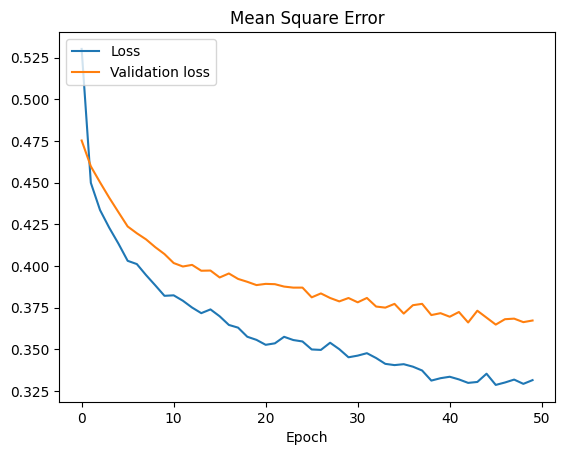

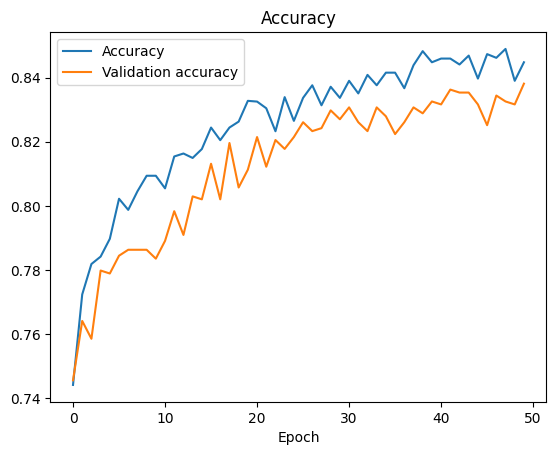

In [29]:
# Visualize the training results – here is an example of how to do it:
print(history.history.keys())

plt.plot(history.history['loss'], label='Loss')
plt.plot(history.history['val_loss'], label='Validation loss')
plt.title('Mean Square Error')
plt.ylabel('')
plt.xlabel('Epoch')
plt.legend(loc="upper left")
plt.show()

plt.plot(history.history['ACC'], label='Accuracy')
plt.plot(history.history['val_ACC'], label='Validation accuracy')
plt.title('Accuracy')
plt.ylabel('')
plt.xlabel('Epoch')
plt.legend(loc="upper left")
plt.show()

## <font color="#CA3532">Evaluación de la red neuronal</font>


In [30]:
# Evaluation (similar to Fit in that it runs one epoch over all the data, but without changing any of the neural network's weights)
loss, accuracy, precision, recall, auc, prc = nn.evaluate(x_train, y_train)
print('Train Accuracy: %.2f' % (accuracy * 100))
print('Train Precision: %.2f' % (precision * 100))
print('Train Recall: %.2f' % (recall * 100))
print('Train AUC: %.2f' % (auc * 100))
print('Train PRC: %.2f' % (prc * 100))

print("-" * 30)

loss, accuracy, precision, recall, auc, prc = nn.evaluate(x_val, y_val)
print('Validation Accuracy: %.2f' % (accuracy * 100))
print('Validation Precision: %.2f' % (precision * 100))
print('Validation Recall: %.2f' % (recall * 100))
print('Validation AUC: %.2f' % (auc * 100))
print('Validation PRC: %.2f' % (prc * 100))

136/136 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - ACC: 0.8651 - P: 0.8025 - PRC: 0.8546 - R: 0.7171 - auc: 0.9316 - loss: 0.3084
Train Accuracy: 86.51
Train Precision: 80.25
Train Recall: 71.71
Train AUC: 93.16
Train PRC: 85.46
------------------------------
34/34 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - ACC: 0.8381 - P: 0.7554 - PRC: 0.7726 - R: 0.6625 - auc: 0.8983 - loss: 0.3672 
Validation Accuracy: 83.81
Validation Precision: 75.54
Validation Recall: 66.25
Validation AUC: 89.83
Validation PRC: 77.26


34/34 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step


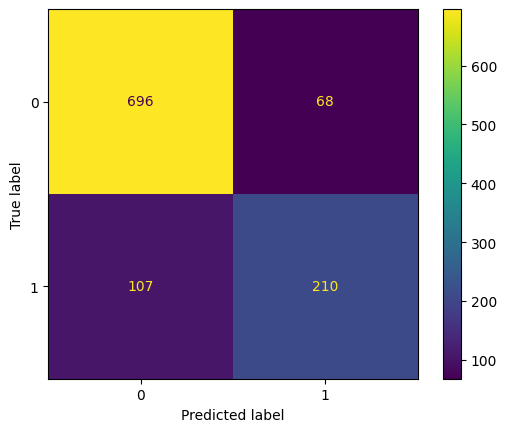

              precision    recall  f1-score   support

         0.0       0.87      0.91      0.89       764
         1.0       0.76      0.66      0.71       317

    accuracy                           0.84      1081
   macro avg       0.81      0.79      0.80      1081
weighted avg       0.83      0.84      0.83      1081



In [31]:
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix
from sklearn.metrics import classification_report
from sklearn.metrics import ConfusionMatrixDisplay

# In addition to "evaluate", there is another method, "predict", which is used to label unlabeled data.
y_pred = nn.predict(x_val)
y_pred = y_pred > 0.5

cm = confusion_matrix(y_val, y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm)
disp.plot()
plt.show()
print(classification_report(y_val, y_pred))

- Modify the neural network architecture by adding more layers and neurons to achieve better results:
  - Add more layers or different types of layers.
  - Change the activation functions.
  - Change the loss function or the optimizer.

### Question 3: Explain in detail the tests carried out and the results obtained.

**Respuesta:**

**1. Pruebas realizadas (Tests carried out):**
Partíamos de un modelo base inicial muy simple (una capa oculta de 10 neuronas, función de activación `sigmoid` y entrenamiento de 20 épocas). Para intentar mejorar su rendimiento, especialmente sobre la clase minoritaria, se realizaron las siguientes modificaciones en la arquitectura:
*   **Aumento de profundidad y neuronas:** Se pasó a tener dos capas ocultas de forma piramidal (una primera capa de 32 neuronas y una segunda de 16 neuronas). Esto permite a la red extraer combinaciones de características no lineales mucho más complejas.
*   **Cambio de función de activación:** Las capas ocultas pasaron de usar `sigmoid` a usar `ReLU`. Esto previene el problema del "desvanecimiento del gradiente", posibilitando que la red aprenda más rápido y no se estanque en mínimos locales.
*   **Inclusión de Regularización:** Se añadió una capa de `Dropout` (con un ratio del 20%) tras la primera capa oculta. En cada iteración del entrenamiento, esto "apaga" aleatoriamente algunas neuronas, impidiendo que la red simplemente memorice los datos (overfitting) y forzándola a encontrar patrones generalizables.
*   **Aumento de iteraciones:** Al tener una red más profunda, se incrementó el tiempo de entrenamiento de 20 a 50 `epochs` para asegurar que la función de coste (Binary Crossentropy) pudiera estabilizarse.

**2. Resultados obtenidos:**
Los resultados demuestran una mejora muy significativa en comparación con la red basíca inicial:
*   **Aciertos generales (Accuracy):** Pasó del 75% al **84%**, lo que indica que globalmente comete muchos menos errores.
*   **Detección de la clase minoritaria (Clase 1 - Vocales Orales):**
    *   El **Recall** subió enormemente del 51% al **66%**. Ahora el modelo es capaz de detectar 210 ejemplos reales de la clase minoritaria, frente a los 162 iniciales (ha reducido los Falsos Negativos de 155 a 107).
    *   La **Precision** de la clase 1 subió del 58% al **76%**. Esto significa que cuando el modelo afirma que una vocal es oral, acierta mucho más que antes y "falla" disparando falsas alarmas con menos frecuencia (los Falsos Positivos han caído de 115 a 68).

*Conclusión temporal:* Modificar la arquitectura introduciendo capas ocultas con ReLU y Dropout supone una gran mejora respecto a una red plana y sigmoidal. Aun así, al ser un problema muy desbalanceado, la clase 1 sigue teniendo peores métricas (Recall de 0.66) que la clase 0 (Recall de 0.91).

## <font color="#CA3532">Neural Network Design Optimization</font>



*Use* RandomSearch to find the hyperparameter values that improve the model’s performance. Check how it works at https://keras.io/keras_tuner/ and https://keras.io/api/keras_tuner/tuners/random/.

In [32]:
from kerastuner.tuners import RandomSearch

/tmp/ipykernel_107095/2610907151.py:1: DeprecationWarning: `import kerastuner` is deprecated, please use `import keras_tuner`.
  from kerastuner.tuners import RandomSearch


In [34]:
# Here is an example you can adapt
import keras_tuner as kt
from keras.models import Sequential
from keras.layers import Dense, Dropout
import keras

def build_model(hp):
    nn = Sequential()
    
    # 1. Buscamos el número de neuronas de la capa 1 y la función de activación
    nn.add(Dense(
        units=hp.Int('units_1', min_value=16, max_value=64, step=16),
        input_dim=x_size, 
        activation=hp.Choice('activation', values=['relu', 'tanh'])
    ))
    
    # 2. Buscamos la tasa óptima de Dropout para evitar el overfitting
    nn.add(Dropout(hp.Float('dropout_rate', min_value=0.1, max_value=0.5, step=0.1)))
    
    # 3. Buscamos el número de neuronas de la capa 2
    nn.add(Dense(
        units=hp.Int('units_2', min_value=8, max_value=32, step=8),
        activation=hp.Choice('activation', values=['relu', 'tanh'])
    ))
    
    # Capa de salida (fija para clasificación binaria)
    nn.add(Dense(1, activation="sigmoid"))
    
    # 4. Buscamos la mejor tasa de aprendizaje (learning rate) para el optimizador Adam
    hp_learning_rate = hp.Choice('learning_rate', values=[1e-2, 1e-3, 1e-4])
    
    # Reutilizamos las métricas anteriores
    metrics = [
        keras.metrics.BinaryAccuracy(name='ACC'),
        keras.metrics.Precision(name='P'),
        keras.metrics.Recall(name='R'),
        keras.metrics.AUC(name='auc'),
        keras.metrics.AUC(name='PRC', curve='PR'),
    ]
    
    nn.compile(
        optimizer=keras.optimizers.Adam(learning_rate=hp_learning_rate), 
        loss="binary_crossentropy", 
        metrics=metrics
    )
    return nn

# Objetivo: Maximizar el área bajo la curva Precision-Recall en Validación (ideal en problemas desbalanceados)
objective = kt.Objective("val_PRC", direction="max")

tuner = kt.RandomSearch(
    build_model, 
    objective=objective, 
    max_trials=10,           # Probará 10 combinaciones aleatorias de hiperparámetros
    executions_per_trial=1,  # Entrenará 1 vez por cada combinación
    directory='busqueda_hiperparametros',
    project_name='clasificacion_vocales',
    overwrite=True           # Sobrescribe búsquedas anteriores si relanzas la celda
)

tuner.search_space_summary()

# Lanzamos la búsqueda con 50 epochs
tuner.search(x_train, y_train, epochs=50, validation_data=(x_val, y_val), verbose=1)

Trial 10 Complete [00h 00m 40s]
val_PRC: 0.7191346883773804

Best val_PRC So Far: 0.8362218737602234
Total elapsed time: 00h 06m 10s


In [35]:
# Extraemos el mejor modelo de los 10 probados. 
# Importante el [0] al final para obtener la red neuronal en sí y no una lista.
best_nn = tuner.get_best_models(num_models=1)[0]

/home/ignacio/Escritorio/NEURO/Neuro/.venv/lib/python3.12/site-packages/keras/src/saving/saving_lib.py:801: UserWarning: Skipping variable loading for optimizer 'adam', because it has 2 variables whereas the saved optimizer has 14 variables. 
  saveable.load_own_variables(weights_store.get(inner_path))


In [36]:
tuner.results_summary()


Results summary
Results in busqueda_hiperparametros/clasificacion_vocales
Showing 10 best trials
Objective(name="val_PRC", direction="max")

Trial 04 summary
Hyperparameters:
units_1: 64
activation: relu
dropout_rate: 0.2
units_2: 24
learning_rate: 0.01
Score: 0.8362218737602234

Trial 05 summary
Hyperparameters:
units_1: 32
activation: tanh
dropout_rate: 0.30000000000000004
units_2: 32
learning_rate: 0.01
Score: 0.8167712092399597

Trial 03 summary
Hyperparameters:
units_1: 48
activation: tanh
dropout_rate: 0.1
units_2: 8
learning_rate: 0.01
Score: 0.8165916204452515

Trial 07 summary
Hyperparameters:
units_1: 64
activation: tanh
dropout_rate: 0.30000000000000004
units_2: 24
learning_rate: 0.01
Score: 0.7880908846855164

Trial 02 summary
Hyperparameters:
units_1: 48
activation: tanh
dropout_rate: 0.4
units_2: 16
learning_rate: 0.01
Score: 0.7659619450569153

Trial 09 summary
Hyperparameters:
units_1: 64
activation: tanh
dropout_rate: 0.4
units_2: 8
learning_rate: 0.001
Score: 0.719134

### Question 4: Explain in detail the optimization performed and the results obtained.



# <font color="#CA3532">Techniques for Unbalanced Problems</font>

We will use some techniques to prepare the data for fitting a model:

- Sampling techniques  
  - Undersampling techniques  
  - Oversampling techniques  

- Cost-sensitive learning techniques

In [ ]:
!pip install -U imbalanced-learn

## <font color="#CA3532">Undersampling Technique</font>

Study how to use [RandomUnderSampler](https://imbalanced-learn.org/stable/references/generated/imblearn.under_sampling.RandomUnderSampler.html) from Imbalance-Learn to create a dataset (based on the original) that contains the same number of majority class examples as minority class examples. Build a model using this data and analyze the results.

In [ ]:
from imblearn.under_sampling import RandomUnderSampler

print(sorted(Counter(y).items()))

rus = RandomUnderSampler(...)
x_resampled, y_resampled = rus.fit_resample(x, y)

print(sorted(Counter(y_resampled).items()))

In [ ]:
from sklearn.model_selection import train_test_split
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix
from sklearn.metrics import classification_report
from sklearn.metrics import ConfusionMatrixDisplay

x_train, x_val, y_train, y_val = train_test_split(x_resampled, y_resampled, test_size=0.2)

history = nn.fit(x_train, y_train, epochs=20, verbose=0, validation_data=(x_val, y_val))

y_pred = nn.predict(x_val)
y_pred = y_pred > 0.5
cm = confusion_matrix(y_val, y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm)
disp.plot()
plt.show()

print(classification_report(y_val, y_pred))

## <font color="#CA3532">Oversampling Technique</font>

Study how to use [RandomOverSampler](https://imbalanced-learn.org/stable/references/generated/imblearn.over_sampling.RandomOverSampler.html#imblearn.over_sampling.RandomOverSampler) from Imbalance-Learn to create a dataset (based on the original) that contains the same number of minority class examples as majority class examples. Build a model using this data and analyze the results.

In [ ]:
from imblearn.over_sampling import RandomOverSampler

print(sorted(Counter(y).items()))

ros = RandomOverSampler(...)
X_resampled, y_resampled = ros.fit_resample(x, y)

print(sorted(Counter(y_resampled).items()))

In [ ]:
x_train, x_val, y_train, y_val = train_test_split(x_resampled, y_resampled, test_size=0.2)

history = nn.fit(x_train, y_train, epochs=20, verbose=0, validation_data=(x_val, y_val))

y_pred = nn.predict(x_val)
y_pred = y_pred > 0.5
cm = confusion_matrix(y_val, y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm)
disp.plot()
plt.show()

print(classification_report(y_val, y_pred))

## <font color="#CA3532">Cost-Sensitive Learning Technique</font>

Study how to use the `class_weight` parameter of the [fit](https://keras.io/api/models/model_training_apis/) method in Keras to assign a different weight to each class, so that this is taken into account during training. Build a model using `class_weight` with the original data and analyze the results.

In [ ]:
x_train, x_val, y_train, y_val = train_test_split(x, y, test_size=0.2)

history = nn.fit(x_train, y_train, epochs=20, verbose=0, class_weight=..., validation_data=(x_val, y_val))

y_pred = nn.predict(x_val)
y_pred = y_pred > 0.5
cm = confusion_matrix(y_val, y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm)
disp.plot()
plt.show()

print(classification_report(y_val, y_pred))

### Question 5: Describe the experiments carried out and the results obtained. You may combine these techniques with hyperparameter search to optimize the models.

<font color="#CA3532">Question 6: General Conclusions</font>

Summarize the work done in this practice and the conclusions you have drawn.